In [ ]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt

In [32]:

def image_grid(shape, recenter:bool = False):
    ny, nx = shape
    cy, cx = (0,0)
    if recenter:
        cy, cx = ny//2, nx//2
    x = np.arange(nx, dtype=float) - cx
    y = np.arange(ny, dtype=float) - cy
    X,Y = np.meshgrid(x, y)
    return X,Y

def get_photocenter(image,offset:bool=False):
    X,Y = image_grid(image.shape)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    if offset:
        qy += 0.5
        qx += 0.5
    return qx,qy 

def get_frame_pupil_centers(frame,thr=0.3,xhalf=100,yhalf=120):
    Y,X = image_grid(frame.shape)
    ll = (X<=xhalf) * (Y<=yhalf)
    lr = (X>xhalf) * (Y<=yhalf)
    ul = (X<=xhalf) * (Y>yhalf)
    ur = (X>xhalf) * (Y>yhalf)
    centers = np.zeros([4,2])
    mask = (frame*ll > thr*np.nanmax(frame*ll)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[0,:] = np.array([qx,qy])
    mask = (frame*lr > thr*np.nanmax(frame*lr)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[1,:] = np.array([qx,qy])
    mask = (frame*ul > thr*np.nanmax(frame*ul)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[2,:] = np.array([qx,qy])
    mask = (frame*ur > thr*np.nanmax(frame*ur)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[3,:] = np.array([qx,qy])
    return centers

[[-34.82729433 -29.13370402]
 [-33.43978634  28.66589045]
 [ 34.51930124 -31.13193683]
 [ 33.74777943  31.59975039]]


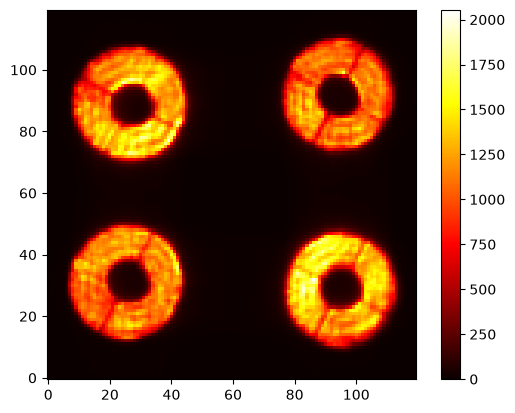

In [52]:
img = np.load('/raid1/mmenessini/calibration/EKARUS/data/OnSky_frame.npy')

ref_centers = get_frame_pupil_centers(img)
avg_center = np.mean(ref_centers,axis=0)
ref_dcenters = ref_centers-avg_center
print(ref_dcenters)

xmin = int(np.round(avg_center[0]))-60
xmax = int(np.round(avg_center[0]))+60
ymin = int(np.round(avg_center[1]))-60
ymax = int(np.round(avg_center[1]))+60

img = img[ymin:ymax,xmin:xmax]

plt.figure()
plt.imshow(img,origin='lower',cmap='hot')
plt.colorbar()

[[ 0.02559801  1.03698995]
 [-0.19945869  0.52225507]
 [-0.12058279  0.39575059]
 [ 0.29444347 -1.95499561]]


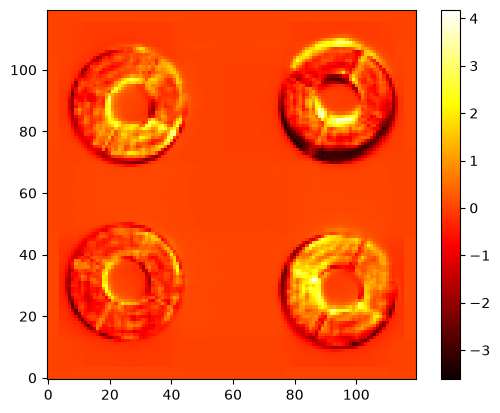

In [183]:
frame = fits.getdata('/raid1/mmenessini/results/EKARUS/frame.fits')[0]

centers = get_frame_pupil_centers(frame,xhalf=60,yhalf=60)
dcenters = centers-np.mean(centers,axis=0)
tilt_coeffs = ref_dcenters.T/30
print(dcenters-ref_dcenters)

plt.figure()
plt.imshow(frame,origin='lower',cmap='hot',vmax=200)
plt.imshow(img/np.mean(img)-frame/np.mean(frame),origin='lower',cmap='hot')
plt.colorbar()